# 자연어와 단어의 분산 표현

자연어 처리가 다루는 분야는 다양하지만, 그 본질적 문제는 컴퓨터가 우리의 말을 알아듣게(이해하게) 만드는 것   
이번 장은 컴퓨터에 말을 이해시킨다는 것이 무슨 뜻인지, 그리고 어떤 방법들이 존재하는지를 중심으로 이야기를 풀어봄   
특히 고전적인 기법(딥러닝 등장 이전의 기법)들을 자세히 살펴보려 함   
딥러닝(정확히는 신경망) 기반 기법들은 잠시 뒤, 다음 장에서 소개함   

또한 이번 장에서는 파이썬으로 텍스트를 다루는 연습도 겸함   
텍스트를 단어로 분할하는 처리나 단어를 단어 ID로 변환하는 처리 등을 구현할 예정   
이번 장에서 구현하는 함수는 다음장 이후에서도 이용함

## 자연어 처리란

한국어와 영어 등 우리가 평소에 쓰는 말을 **자연어(natural laguage)** 라고 함   
그러니 **자연어 처리(Natural Language Processing, NLP)** 를 문자 그대로 해석하면 '자연어를 처리하는 분야'이고,   
알기 쉽게 풀어보면 '우리의 말을 컴퓨터에게 이해시키기 위한 기술(분야)'   
그래서 자연어 처리가 추구하는 목표는 사람의 말을 컴퓨터가 이해하도록 만들어서, 컴퓨터가 우리에게 도움이 되는 일을 수행하게 하는 것   

컴퓨터가 이해할 수 있는 언어라고 하면 '프로그래밍 언어'나 '마크업 언어'와 같은 것을 생각할 수 있음   
이러한 언어는 모든 코드의 의미를 고유하게 해석할 수 있도록 문법이 정의되어 있고, 컴퓨터는 이 정해진 규칙에 따라서 코드를 해석함   

알다시피, 일반적인 프로그래밍 언어는 기계적이고 고정되어 있음 - '딱딱한 언어'라는 뜻   
반면, 영어나 한국어 같은 자연어는 '부드러운 언어' - 똑같은 의미의 문장도 여러 형태로 표현할 수 있거나, 문장의 뜻이 애매할 수 있거나, 그 의미나 형태가 유연하게 바뀐다는 뜻   
세월이 흐르면서 새로운 말이나 새로운 의미가 생겨나거나 있던 것이 사라지기도 함, 이 모두가 자연어가 부드럽기 때문   

이처럼 자연어는 살아 있는 언어이며 그 안에는 '부드러움'이 있음   
따라서 머리가 굳은 컴퓨터에게 자연어를 이해시키기란 평범한 방법으로는 도달할 수 없는 어려움   
하지만 컴퓨터에게 자연어를 이해시키 수 있다면 수많은 사람에게 도움되는 일을 컴퓨터에게 시킬 수 있음   
그 예시는 흔하게 볼 수 있음   
- 검색 엔진이나 기계 번역
- 질의응답 시스템
- IME(입력기 전환)
- 문장 자동요약과 감정분석 등   

> 자연어 처리를 응용한 예로 '질의응답 시스템'이 있음   
> 그 대표주자인 IBM 왓슨(Watson)은 아주 유명함   
> 왓슨은 2011년 미국의 TV 퀴즈쇼 '제퍼디'를 통해서 세상에 널리 알려짐   
> 이 퀴즈 쇼에서 왓슨은 어떤 사람보다도 더 정확하게 대답하여 기존 챔피언을 물리치고 우승했음(왓슨에게는 문제가 텍스트로 주어진다는 이점이 있긴 했음)   
> 이 사건은 세상의 이목을 집중시켰고, 인공지능에 대한 기대와 동시에 불안까지도 키우는 계기가 되었음   
> 또한 왓슨은 '의사결정 지원 시스템'으로 분야를 넓혀, 과거의 방대한 의료 데이터를 활용해 난치병 환자에게 올바른 치료법을 제안해 목숨을 구한 사례도 있음

### 단어의 의미

우리의 말은 '문자'로 구성되며, 말의 의미는 '단어'로 구성됨   
단어는 말하자면 의미의 최소 단위인 셈   
그래서 자연어를 컴퓨터에게 이해시키는 데는 무엇보다 '단어의 의미'를 이해시키는 게 중요함   

이번 장의 주제는 컴퓨터에게 '단어의 의미' 이해시키기   
더 정확히 말하면 '단어의 의미'를 잘 파악하는 표현 방법에 관해 생각해봄   
구체적으로는 이번 장과 다음 장에서 다음 3가지 기법을 살펴봄   
- 시소러스를 활용한 기법 (이번장)
- 통계 기반 기법 (이번장)
- 추론 기반 기법(word2vec) (다음장)   

가장 먼저, 사람의 손으로 만든 시소러스(thesaurus)(유의어 사전)를 이요하는 방법을 간단히 살펴봄   
그런 다음 통계 정보로부터 단어를 표현하는 '통계 기반 기법'을 설명함   
그 뒤를 이어 다음 장에서는 신경망을 활용한 '추론 기반' 기법(word2vec)을 다룸   

## 시소러스

'단어의 의미'를 나타내는 방법으로는 먼저 사람이 직접 단어의 의미를 정의하는 방식을 생각할 수 있음   
그중 한 방법으로 <표준국어대사전> 처럼 각각의 단어에 그 의미를 설명해 넣을 수 있을 것   
예컨대 '자동차'라는 단어를 찾으면 '원동기를 장치하여 그 동력으로 바퀴를 굴려서 철길이나 가설된 선에 의하지 아니하고 땅 위를 움직이도록 만든 차' 라는 설명이 나옴   
이런 식으로 단어들을 정의해두면 컴퓨터도 단어의 의미를 이해할 수 있을지도 모름   

자연어 처리의 역사를 되돌아보면 단어의 의미를 인력을 동원해 정의하려는 시도는 수없이 있어왔음   
단, 사람이 이용하는 일반적인 사전이 아니라 **시소러스** 형태의 사전을 이요 ㅇ함   
시소러스란 (기본적으로) 유의어 사전으로, '뜻이 같은 단어(동의어)'나 '뜻이 비슷한 단어(유의어)'가 한 그룹으로 분류되어 있음   
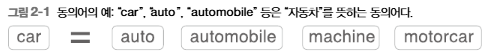   

또한 자연어 처리에 이용되는 시소러스에서는 단어 사이의 '상위와 하위' 혹은 '전체와 부분' 등, 더 세세한 관계까지 정의해둔 경우가 있음   
아래 그림처럼 각 단어의 관계를 그래프 구조로 정의함   
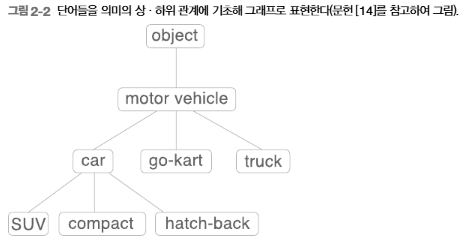   
- 그림에서는 'car'의 상위 개념으로 'motor vehicle(동력차)'이라는 단어가 존재함   
- 한편 'car'의 하위 개념으로는 'SUV(스포츠 유틸리티 자동차)', 'compact(소형차)', 'hatch-back(해치백)' 등 더 구체적인 차종이 있음을 알려줌   

이처럼 모든 단어에 대한 유의어 집합을 만든 다음, 단어들의 관계를 그래프를 표현하여 단어 사이의 연결을 정의할 수 있음   
그러면 이 '단어 네트워크'를 이용하여 컴퓨터에게 단어 사이의 관계를 가르칠 수 있음   
그리고 그 지식을 이용하면 우리에게 유용한 일들을 컴퓨터가 수행하도록 할 수 있음   

> 시소러스를 어떻게 사용하는가는 자연어 처리 애플리케이션에 따라 다름   
> 검색 엔진을 예로 생각해보면   
> 'automobile'과 'car'가 유의어임을 알고 있으면 'car'의 검색 결과에 'automobile'의 검색 결과도 포함시켜주면 좋을 것   

### WordNet

자연어 처리 분야에서 가장 유명한 시소러스는 **WordNet**   
WordNet은 프리스턴 대학교에서 1985년부터 구축하기 시작한 전통 있는 시소러스로, 지금까지 많은 연구와 다양한 자연어 처리 애플리케이션에서 활용되고 있음   

WordNet을 사용하면 유의어를 얻거나 '단어 네트워크'를 이용할 수 있음   
또한 단어 네트워크를 사용해 단어 사이의 유사도를 구할 수 있음   
이 책에서는 WordNet을 자세히 설명하지는 않으니, WordNet을 사용한 파이썬 구현에 흥미가 있으면 '부록 WordNwt 맛보기' 참고   
- 부록에서는 WordNet(정확하게는 NLTK 모듈)을 설치하고 몇 가지 간단한 실험을 해봄   

### 시소러스의 문제점

WordNet과 같은 시소러스에는 수많은 단어에 대한 동의어와 계층 구조 등의 관계가 정의되어 있음   
이 지식을 이용하면 '단어의 의미'를 (간접적으로라도) 컴퓨터에 전달할 수 있음   
하지만 이처럼 사람이 수작업으로 레이블링하는 방식에는 크나큰 결점이 존재함   
다음은 시소러스 방식의 대표적인 문제점들   
- 시대 변화에 대응하기 어려움
    - 우리가 사용하는 말은 살아 있음
    - 새로운 단어가 생겨나고, 옛말은 언젠가 잊혀짐
    - 또한 시대에 따라 언어의 의미가 변하기도 함
    - 이런 단어의 변화에 대응하려면 시소러스를 사람이 수작업으로 끊임없이 갱신해야 함
- 사람을 쓰는 비용은 큼
- 단어의 미묘한 차이를 표현할 수 없음

이처럼 시소러스를 사용하는 기법(단어의 의미를 사람이 정의하는 기법)에는 큰 문제가 있음   
이 문제를 해결하기 위해 '통계 기반 기법'과 신경망을 사용한 '추론 기반 기법'을 알아볼 것   
이 두 기법에서는 대량의 텍스트 데이터로부터 '단어의 의미'를 자동으로 추출함   

> 자연어 처리뿐 아니라, 이미지 인식에서도 특징(feature)을 사람이 수동으로 설계하는 일이 오랜 세월 계속되어 왔음   
> 그러다가 딥러닝이 실용화되면서 실생활 이미지로부터 원하는 결과를 곧바로 얻을 수 있게 되었음   
> 사람이 개입할 필요가 현격히 줄어든 것   
> 자연어 처리에서도 똑같은 일이 벌어지고 있음   
> 즉, 사람이 수작업으로 시소러스나 관계(특징)를 설계하던 방식으로부터, 사람의 개입을 최소로 줄이고 텍스트 데이터만으로 원하는 결과를 얻어내는 방향으로 패러다임이 바뀌고 있음   

## 통계 기반 기법

이제부터 통계 기반 기법을 살펴보면서 우리는 **말뭉치(corpus)** 를 이용할 것   
말뭉치란 간단히 말하면 대량의 텍스트 데이터   
다만 맹목적으로 수집된 텍스트 데이터가 아닌 자연어 처리 연구나 애플리케이션을 염두에 두고 수집된 텍스트 데이터를 일반적으로 '말뭉치'라고 함   

결국 말뭉치란 텍스트 데이터에 지나지 않지만, 그 안에 담긴 문장들은 사람이 쓴 글   
다른 시각에서 생각해보면, 말뭉치에는 자연어에 대한 사람의 '지식'이 충분히 담겨 있다고 볼 수 있음   
문장을 쓰는 방법, 단어를 선택하는 방법, 단어의 의미 등 사람이 알고 있는 자연어에 대한 지식이 포함되어 있는 것   
통계 기반 기법의 목표는 이처럼 사람의 지식으로 가득한 말뭉치에서 자동으로, 그리고 효울적으로 그 핵심을 추출하는 것   

> 자연어 처리에 사용되는 말뭉치에는 텍스트 데이터에 대한 추가 정보가 포함되는 경우가 있음   
> 예컨대 텍스트 데이터의 단어 각각에 '품사'가 레이블링될 수 있음   
> 이럴 경우 말뭉치는 컴퓨터가 다루기 쉬운 형태(트리 구조 등)로 가공되어 주어지는 것이 일반적   
> 이 책에서는 이러한 추가 레이블을 이용하지 않고, 단순한 텍스트 데이터(하나의 큰 텍스트 파일)로 주어졌다고 가정함   

### 파이썬으로 말뭉치 전처리하기

자연어 처리에는 다양한 말뭉치가 사용됨   
유명한 것으로는 위키백과(Wikipedia)와 구글 뉴스(Google News) 등의 텍스트 데이터가 있음   
또한 셰익스피어나 나쓰메 소세키 같은 대문호의 작품들도 말뭉치로 이용됨   
이번 장에서는 우선 문장 하나로 이뤄진 단순한 텍스트를 사용함   
그런 후에 더 실용적인 말뭉치도 다뤄봄   

그러면 파이썬의 대화 모드를 이용하여 매우 작은 텍스트 데이터(말뭉치)에 전처리(preprocessing)를 해보기   
여기서 말하는 전처리란 텍스트 데이터를 단어로 분할하고 그 분할된 단어들을 단어 ID 목록으로 변환하는 일   

그럼, 하나씩 확인하면서 단계별로 진행   
우선 이번 말뭉치로 이용할 예시 문장부터 보면   

In [1]:
text = 'You say goodbye and I say hello.'

이번 절에서는 이처럼 문장 하나로 이뤄진 텍스트를 이용함   
실전이라면 이 text에 수천, 수만 개가 넘는 문장이 (연이어) 담겨 있을 것   
하지만 지금은 쉽게 설명하기 위해 이 작은 텍스트 데이터만으로 전처리를 수행함   
이 text를 단어 단위로 분할하면   

In [2]:
text = text.lower()
text = text.replace('.', ' .')
print(text)

words = text.split(' ')
print(words)

you say goodbye and i say hello .
['you', 'say', 'goodbye', 'and', 'i', 'say', 'hello', '.']


- 가장 먼저 lower() 메서드를 사용해 모든 문자를 소문자로 변환
- 문장 첫머리의 대문자로 시작하는 단어도 소문자 단어와 똑같이 취급하기 위한 조치   
- 그리고 split(' ') 메서드를 호출해 공백을 기준으로 분할
- 다만 여기에서는 문장 끝의 마침표 (.)를 고려해 마침표 앞에 공백을 삽입 (정확하게는 '.'를 ' .'로 변환)한 다음 분할을 수행했음   

> 여기에서 단어를 분할할 때 마침표 앞에 공백을 넣는 임시변통을 적용했지만, 더 현명하고 범용적인 방법이 있음   
> 바로 '정규표현식(regular expression)'을 이용하는 방법   
> 예를 들어 정규표현식 모듈인 re를 임포트하고 re.split('(\W+)?', text) 라고 호출하면 단어 단위로 분할할 수 있음   
> 정규표현식에 관한 상세한 설명은 『정규표현식』 (제이펍, 2016) 등의 다른 책을 참고   

이제 원래의 문장을 단어 목록 형태로 이용할 수 있게 되었음   
단어 단위로 분할되어 다루기가 쉬워진 것은 사실이지만, 단어를 텍스트 그대로 조작하기란 여러 면에서 불편   
그래서 단어에 ID를 부여하고, ID의 리스트로 이용할 수 있도록 한 번 더 손질함   
이를 위한 사전 준비로, 파이썬의 딕셔너리를 이용하여 단어 ID와 단어를 짝지어주는 대응표를 작성   

In [3]:
word_to_id = {}
id_to_word = {}

for word in words:
    if word not in word_to_id:
        new_id = len(word_to_id)
        word_to_id[word] = new_id
        id_to_word[new_id] = word

- 단어 ID에서 단어로의 변환은 id_to_word가 담당하며(키가 단어 ID, 값이 단어), 단어에서 단어 ID로의 변환은 word_to_id가 담당   
- 단어 단위로 분할된 words의 각 원소를 처음부터 하나씩 살펴보면서, 단어가 word_to_id에 들어 있지 않으면 word_to_id와 id_to_word 각각에 새로운 ID와 단어를 추가   
- 또한 추가 시점의 딕셔너리 길이가 새로운 단어의 ID로 설정되기 때문에 단어 ID는 0, 1, 2, … 식으로 증가

이것으로 단어 ID와 단어의 대응표가 만들어졌음   
그렇다면 실제 어떤 내용이 담겨 있는지 살펴보면

In [4]:
print(id_to_word)
print(word_to_id)

{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}
{'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}


- 이처럼 딕셔너리를 사용하면 단어를 가지고 단어ID를 검색하거나, 반대로 단어 ID를 가지고 단어를 검색할 수 있음   

다음 예를 보면

In [5]:
print(id_to_word[1])
print(word_to_id['hello'])

say
5


그럼 마지막으로 '단어 목록'을 ‘단어 ID 목록’으로 변경해보기   
다음 코드에서는 파이썬의 내포(comprehension) 표기를 사용하여 단어 목록에서 단어 ID 목록으로 변환한 다음, 다시 넘파이 배열로 변환함

In [6]:
import numpy as np

corpus = [word_to_id[w] for w in words]
corpus = np.array(corpus)
print(corpus)

[0 1 2 3 4 1 5 6]


> 내포란 리스트나 딕셔너리 등의 반복문 처리를 간단하게 쓰기 위한 기법   
> 예컨대 xs = [1, 2, 3, 4]라는 리스트의 각 원소를 제곱하여 새로운 리스트를 만들고 싶다면 [x**2 for x in xs]처럼 쓰면 됨   

이것으로 말뭉치를 이용하기 위한 사전 준비를 마침   
위 내용을 모아 preprocess()라는 함수로 만들어보면

In [7]:
def preprocess(text):
    text = text.lower()
    text = text.replace('.', ' .')
    words = text.split(' ')

    word_to_id = {}
    id_to_word = {}
    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word
        
    corpus = np.array([word_to_id[w] for w in words])

    return corpus, word_to_id, id_to_word

- 이 함수를 사용하면 말뭉치 전처리를 다음과 같이 수행할 수 있음

In [8]:
text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

이것으로 말뭉치 전처리가 끝남   
여기서 준비한 corpus, word_to_id, id_to_word라는 변수 이름은 앞으로 이 책의 곳곳에서 등장함   
- corpus는 단어 ID 목록 
- word_to_id는 단어에서 단어 ID로의 딕셔너리
- id_to_word는 단어 ID에서 단어로 딕셔너리를 뜻함   

이제 말뭉치를 다룰 준비가 끝났고 다음 목표는 말뭉치를 사용해 '단어의 의미'를 추출하는 것   
그 한 방법으로, 이번 절에서는 '통계 기반 기법'을 살펴봄   
이 기법을 사용해 우리는 단어를 벡터로 표현할 수 있게 될 것

### 단어의 분산 표현

세상은 다채로운 색으로 가득함   
이러한 색들에는 코발트블루, 싱크레드 같은 고유한 이름을 붙일 수도 있음   
그리고 RGB라는 세 가지 성분이 어떤 비율로 섞여 있느냐로 표현하는 방법도 있음   
이 방법은 색을 3차원의 벡터로 표현함   

여기서 주목할 점은 RGB 같은 벡터 표현이 색을 더 정확하게 명시할 수 있다는 점   
게다가 모든 색을 단 3개의 성분으로 간결하게 표현할 수 있고, (많은 경우) 어떤 색인지 짐작하기도 쉬움   
예컨대 '비색'이라고 하면 어떤 색인지 몰라도, (R, G, B) = (170, 33, 22)라고 하면 빨강 계열의 색임을 알 수 있음   

또한 색끼리의 관련성(비슷한 색인지 여부 등)도 벡터 표현 쪽이 더 쉽게 판단할 수 있고, 정량화하기도 쉬움   

그러면 '색'을 벡터로 표현하듯 '단어'도 벡터로 표현할 수 있을까?   
(조금 어렵긴 하지만) 더 정확하게 말하자면, 간결하고 이치에 맞는 벡터 표현을 단어라는 영역에서도 구축할 수 있을까?   
이제부터 우리가 원하는 것은 '단어의 의미'를 정확하게 파악할 수 있는 벡터 표현   
이를 자연어 처리 분야에서는 단어의 분산 표현(distributional representation)이라고 함   

> 단어의 분산 표현은 단어를 고정 길이의 밀집벡터(dense vector)로 표현함   
> 밀집벡터란 대부분의 원소가 0이 아닌 실수인 벡터를 말함   
> 예컨대 3차원의 분산 표현은 [0.21, -0.45, 0.83]과 같은 모습이 됨   
> 이러한 단어의 분산 표현을 어떻게 구축할 것인가가 앞으로 살펴볼 중요한 주제

### 분포 가설

자연어 처리의 역사에서 단어를 벡터로 표현하는 연구는 수없이 이뤄져 왔음   
그 연구들을 살펴보면, 중요한 기법의 거의 모두가 단 하나의 간단한 아이디어에 뿌리를 두고 있음을 알 수 있음   
그 아이디어는 바로 '단어의 의미는 주변 단어에 의해 형성된다'라는 것   
이를 분포 가설(distributional hypothesis)이라 하며, 단어를 벡터로 표현하는 최근 연구도 대부분 이 가설에 기초함   

분포 가설이 말하고자 하는 바는 매우 간단함   
단어 자체에는 의미가 없고, 그 단어가 사용된 '맥락(context)'이 의미를 형성한다는 것   
물론 의미가 같은 단어들은 같은 맥락에서 더 많이 등장함   
예컨대 "I drink beer"와 "We drink wine"처럼 "drink"의 주변에는 음료가 등장하기 쉬울 것   
또, "I guzzle beer"와 "We guzzle wine"이라는 문장이 있다면, 'guzzle'은 'drink'와 같은 맥락에서 사용됨을 알 수 있음   
그리고 'guzzle'과 'drink'는 가까운 의미의 단어라는 것도 알 수 있음(참고로 'guzzle'의 뜻은 '폭음하다')   

앞으로는 '맥락'이라는 말을 자주 사용할 것   
이번 장에서 '맥락'이라 하면 (주목하는 단어) 주변에 놓인 단어를 가리킴   
예컨대 아래 그림에서는 좌우의 각 두 단어씩이 '맥락'에 해당   
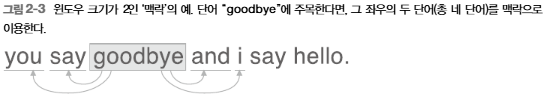   
- 그림처럼 '맥락'이란 특정 단어를 중심에 둔 그 주면 단어를 말함   
- 그리고 맥락의 크기(주변 단어를 몇 개나 포함할지)를 '윈도우 크기(window size)'라고 함
- 위도우 크기가 1이면 좌우 한 단어씩, 윈도우 크기가 2이면 좌우 두 단어씩이 맥락에 포함됨   

> 여기에서는 좌우로 똑같은 수의 단어를 맥락으로 사용했음   
> 하지만 상황에 따라서는 왼쪽 단어만 또는 오른쪽 단어만을 사용하기도 하며, 문장의 시작과 끝을 교려할 수도 있음   
> 이 책에서는 이해하기 쉽게 설명하고자 문장 구분은 고려하지 않고 좌우 동수인 맥락만을 취급함

### 동시발생 행렬

그러면 분포 가설에 기초해 단어를 벡터로 나타내는 방법을 생각해보면 주변 단어를 '세어보는' 방법이 자연스럽게 떠오를 것   
어떤 단어에 주목했을 때, 그 주변에 어떤 단어가 몇 번이나 등장하는지를 세어 집계하는 방법   
이 책에서는 이를 '통계 기반(statistical based)' 기법이라고 함   

그럼 통계 기반 기법을 살펴보면   
먼저 '파이썬으로 말뭉치 전처리하기' 절에서 봤던 말뭉치와 preprocess() 함수를 사용해 전처리하는 일부터 시작

In [17]:
import sys
import numpy as np

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

print(corpus)
print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


- 결과를 보면 단어 수가 총 7개임을 알 수 있음   
- 다음으로는 각 단어의 맥락에 해당하는 단어의 빈도를 세어봄   
- 윈도우 크기는 1로 하고, 단어 ID가 0인 'you'부터 시작   
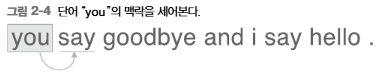   
- 그림에서 쉽게 알 수 있듯, 단어 'you'의 맥락은 'say'라는 단어 하나뿐   
- 이를 표로 정리하면   
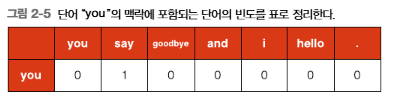   
- 위 그림은 단어 'you'의 맥락으로써 동시에 발생(등장)하는 단어의 빈도를 나타낸 것   
- 그리고 이를 바탕으로 'you'라는 단어를 [0, 1, 0, 0, 0, 0, 0]이라는 벡터로 표현할 수 있음   

계속해서 ID가 1인 'say'에 대해서도 같은 작업을 수행함   
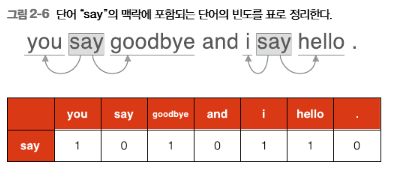   
- 이 결과로부터 'say'라는 단어는 벡터 [1, 0, 1, 0, 1, 1, 0]으로 표현할 수 있음   

이상의 작업을 모든 단어(이번 예에서는 총 7개 단어)에 대해서 수행한 결과는   
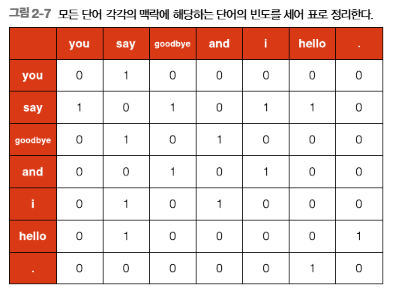   
- 그림은 모든 단어에 대해 동시발생하는 단어를 표에 정리한 것
- 이 표의 각 행은 해당 단어를 표현한 벡터가 됨   
- 참고로 이 표가 행렬의 형태를 띤다는 뜻에서 **동시발생 행렬(co-occurrence matrix)** 이라고 함   

그럼 그림의 동시발생 행렬을 파이썬으로 구현해보면   
(여기에서는 그림 그대로를 손으로 입력해봄)

In [18]:
C = np.array([
    [0, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 0]
], dtype=np.int32)

- 이걸로 동시발생 행렬이 생김   
- 이 동시발생 행렬을 사용하면 다음과 같은 방식으로 각 단어의 벡터를 얻을 수 있음

In [19]:
print(C[0])  # ID가 0인 단어의 벡터 표현
print(C[4])  # ID가 4인 단어의 벡터 표현
print(C[word_to_id['goodbye']])  # 'goodbye'의 벡터 표현

[0 1 0 0 0 0 0]
[0 1 0 1 0 0 0]
[0 1 0 1 0 0 0]


이와 같이 동시발생 행렬을 활용하면 단어를 벡터로 나타낼 수 있음   
이번에는 동시발생 행렬을 수동으로 만들었지만, 당연히 자동화할 수도 있음   

그러면 말뭉치로부터 동시발생 행렬을 만들어주는 함수를 구현해보기   
- 함수 이름은 create_co_matrix(corpus, vocab_size, window_size=1)   
- 인수들은 차례로 단어 ID의 리스트, 어휘 수, 윈도우 크기

In [21]:
def create_co_matrix(corpus, vocab_size, window_size=1):
    corpus_size = len(corpus)
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    for idx, word_id in enumerate(corpus):
        for i in range(1, window_size + 1):
            left_idx = idx - 1
            right_idx = idx + 1
            
            if left_idx >= 0:
                left_word_id = corpus[left_idx]
                co_matrix[word_id, left_word_id] += 1

            if right_idx < corpus_size:
                right_word_id = corpus[right_idx]
                co_matrix[word_id, right_word_id] += 1
    
    return co_matrix

- 이 함수는 먼저 co_matrix를 0으로 채워진 2차원 배열로 초기화함
- 그다음은 말뭉치의 모든 단어 각각에 대하여 윈도우에 포함된 주변 단어를 세어나감
- 이때 말뭉치의 왼쪽 끝과 오른쪽 끝 경계를 벗어나지 않는지도 확인함   

이 함수는 말뭉치가 아무리 커지더라도 자동으로 동시발생 행렬을 만들어줌   
앞으로 말뭉치의 동시발생 행렬을 만들 떄면 언제나 이 함수를 사용

### 벡터 간 유사도

앞에서 동시발생 행렬을 활용해 단어를 벡터로 표현하는 방법을 알아봤음   
계속해서 벡터 사이의 유사도를 측정하는 방법을 알아봄   

벡터 사이의 유사도를 측정하는 방법은 다양함   
대표적으로는 벡터의 내적이나 유클리드 거리 등을 꼽을 수 있음   
그 외에도 다양하지만, 단어 벡터의 유사도를 나타낼 때는 **코사인 유사도(cosine similarity)** 를 자주 이용함   
두 벡터 x = (x1, x2, x3, ..., xn)과 y = (y1, y2, y3, ..., yn)이 있다면, 코사인 유사도는 다음 식으로 정의됨   
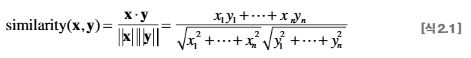   
- 식의 분자에는 벡터의 내적이, 분모에는 각 벡터의 노름(norm)이 등장함   
- 노름은 벡터의 크기를 나타낸 것으로, 여기에서는 'L2 노름'을 계산함(L2 노름은 벡터의 각 원소를 제곱해 더한 후 다시 제곱근을 구해 계산)
- 이 식의 핵심은 벡터를 정규화하고 내적을 구하는 것   

> 코사인 유사도를 직관적으로 풀어보자면 '두 벡터가 가리키는 방향이 얼마나 비슷한가'   
> 두 벡터의 방향이 완전히 같다면 코사인 유사도가 1이 되며, 완전히 반대라면 -1이 됨   

이제 코사인 유사도를 파이썬으로 구현

In [23]:
def cos_similarty(x, y):
    nx = x / np.sqrt(np.sum(x**2))  # x의 정규화
    ny = y / np.sqrt(np.sum(y**2))  # y의 정규화
    return np.dot(nx, ny)

- 이 코드에서 인수 x와 y는 넘파이 배열이라고 가정   
- 이 함수는 먼저 벡터 x와 y를 정규화한 후 두 벡터의 내적을 구함   
- 이렇게만 해도 코사인 유사도를 구할 수 있지만, 이 구현에는 문제가 하나 있음   
- 인수로 제로 벡터(원소가 모두 0인 벡터)가 들어오면 '0으로 나누기(divide by zero)' 오류가 발생해버림   
- 이 문제를 해결하는 전통적인 방법은 나눌 때 분모에 작은 값을 더해주는 것   
- 작은 값을 뜻하는 eps를 인수로 받도록 하고, 이 인수의 값을 지정하지 않으면 기본값으로 1e-8(=0.00000001)이 설정되도록 수정(eps는 엡실론(epsilon)의 약어)

이렇게 개선하면

In [24]:
def cos_similarty(x, y, eps=1e-8):
    nx = x / np.sqrt(np.sum(x**2) + eps)  # x의 정규화
    ny = y / np.sqrt(np.sum(y**2) + eps)  # y의 정규화
    return np.dot(nx, ny)

> 여기에서 작은 값으로 1e-8을 사용했는데, 이 정도 작은 값이면 일반적으로 부동소수점 계산 시 '반올림'되어 다른 값에 '흡수'됨   
> 앞의 구현에서는 이 값이 벡터의 노름에 '흡수'되기 때문에 대부분의 경우 eps를 더한다고 해서 최종 계산 결과에는 영향을 주지 않음   
> 한편, 벡터의 노름이 0일 때는 이 작은 값이 그대로 유지되어 '0으로 나누기' 오류가 나는 사태를 막아줌   

이 함수를 사용하면 단어 벡터의 유사도를 다음과 같이 구할 수 있음   
다음은 'you'와 'i(=I)'의 유사도를 구하는 코드

In [29]:
text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)

c0 = C[word_to_id['you']]  # 'you'의 단어 벡터
c1 = C[word_to_id['i']]  # 'i'의 단어 벡터
print(cos_similarty(c0, c1))

0.7071067758832467


- 실행 결과 'you'와 'i'의 코사인 유사도는 0.70...으로 나왔음 
- 코사인 유사도 값은 -1에서 1 사이이므로, 이 값은 비교적 높다(유사성이 크다)고 말할 수 있음

### 유산 단어의 랭킹 표시

코사인 유사도까지 구현했으니 이 함수를 활용해 또 다른 유용한 기능을 구현   
어떤 단어가 검색어로 주어지면, 그 검색어와 비슷한 단어를 유사도 순으로 출력하는 함수   
그 함수 이름은 most_similar()로 하고, 다음 인수들을 입력받도록 구현   
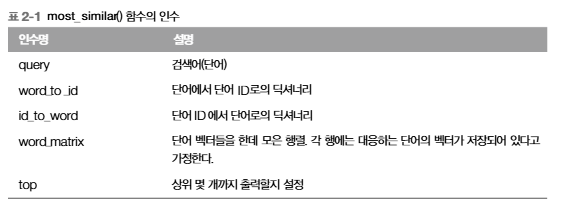   

most_similar() 함수의 구현은 다음과 같음

In [30]:
def most_similar(query, word_to_id, id_to_word, word_matrix, top=5):
    # 1. 검색어를 꺼냄
    if query not in word_to_id:
        print('%s(을)를 찾을 수 없습니다.' % query)
        return
    
    print('\n[query] ' + query)
    query_id = word_to_id[query]
    query_vec = word_matrix[query_id]

    # 2. 코사인 유사도 계산
    vocab_size = len(id_to_word)
    similarity = np.zeros(vocab_size)
    for i in range(vocab_size):
        similarity[i] = cos_similarty(word_matrix[i], query_vec)
    
    # 3. 코사인 유사도를 기준으로 내림차순으로 출력
    count = 0
    for i in (-1 * similarity).argsort():
        if id_to_word[i] == query:
            continue
        print(' %s: %s' % (id_to_word[i], similarity[i]))

        count += 1
        if count >= top:
            return

- 이 코드는 다음 순서로 동작함
    1. 검색어의 단어 벡터를 꺼냄
    2. 검색어의 단어 벡터와 다른 모든 단어 벡터와의 코사인 유사도를 각각 구함
    3. 계산한 코사인 유사도 결과를 기준으로 값이 높은 순서대로 출력

3번 코드에서는 similarity 배열에 담긴 원소의 인덱스를 내림차순으로 정렬한 후 상위 원소들을 출력함   
이때 배열 인덱스의 정렬을 바꾸는 데 사용한 argsort() 메서드는 넘파이 배열의 원소를 오름차순으로 정렬함(단, 반환값은 배열의 인덱스)   

이제 위 함수를 사용해보면   
'you'를 검색어로 지정해 유사한 단어들을 출력

In [31]:
text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)

most_similar('you', word_to_id, id_to_word, C, top=5)


[query] you
 goodbye: 0.7071067758832467
 hello: 0.7071067758832467
 i: 0.7071067758832467
 and: 0.0
 say: 0.0


- 이 결과는 검색어 'you'와 유사한 단어를 상위 5개만 출력한 것, 코사인 유사도는 해당 단어의 오른쪽에서 볼 수 있음
- 앞의 결과를 보면 'you'에 가장 가까운 단어는 총 3개인데, 차례로 'goodbye', 'i(=I)', 'hello' 
- 확실히 'i'와 'you' 모두 인칭대명사이므로 둘이 비슷하다는 건 납득이 됨 
- 하지만 'goodbye'와 'hello'의 코사인 유사도가 높다는 것은 우리의 직관과는 거리가 멈
- 물론 지금은 말뭉치의 크기가 너무 작다는 것이 원인
- 나중에 더 큰 말뭉치를 사용하여 똑같은 실험을 해볼 것   

지금까지 본 것처럼 동시발생 행렬을 이용하면 단어를 벡터로 표현할 수 있음   
이것으로 통계 기반 기법의 '기본'을 끝마침   
지금까지가 '기본'인 만큼, 다음 절에서는 지금의 방법을 한층 개선하는 아이디어를 설명하고 실제로 구현해볼 것

## 통계 기반 기법 개선하기

앞 절에서는 단어의 동시발생 행렬을 만들었음   
이를 이용해 단어를 벡터로 표현하는 데는 성공했는데, 사실 동시발생 행렬에는 아직 개선할 점이 있음   
이번 절에서는 이 개선 작업을 함   
그리고 개선을 완료한 다음에는 더 실용적인 말뭉치를 사용하여 '진짜' 단어의 분산 표현을 손에 넣어볼 것

### 상호정보량

앞 절에서 본 동시발생 행렬의 원소는 두 단어가 동시에 발생한 횟수를 나타냄   
그러나 이 '발생' 횟수라는 것은 사실 그리 좋은 특징이 아님   
고빈도 단어(많이 출현하는 단어)로 눈을 돌려보면 그 이유를 바로 알 수 있음   

예컨대 말뭉치에서 'the'와 'car'의 동시발생을 생각해보면   
분명 '... the car ...'라는 문구가 자주 보일 것   
따라서 두 단어의 동시발생 횟수는 아주 많음   
한편, 'car'와 'drive'는 확실히 관련이 깊음   
하지만 단순히 등장 횟수만을 본다면 'car'는 'drive'보다는 'the'와의 관련성이 훨씬 강하다고 나올 것   
'the'가 고빈도 단어라서 'car'와 강한 관련성을 갖는다고 평가되기 때문   

이 문제를 해결하기 위해 **점별 상호정보량(Pointwise Mutual Information)(PMI)** 이라는 척도를 사용   
PMI는 확률 변수 x와 y에 대해 다음 식으로 정의됨(확률에 관해서는 이후에 다룸)   
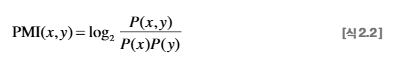   
- 식에서 P(x)는 x가 일어날 확률, P(y)는 y가 일어날 확률, P(x, y)는 x와 y가 동시에 일어날 확률을 뜻함
- 이 PMI 값이 높을수록 관련성이 높다는 의미
- 이 식을 앞의 자연어 예에 적용하면 P(x)는 단어 x가 말뭉치에 등장할 확률을 가리킴
- 예컨대 10,000개의 단어로 이뤄진 말뭉치에서 'the'가 100번 등장한다면 이 됨
- 또한 P(x, y)는 단어 x와 y가 동시발생할 확률이므로, 마찬가지로 'the'와 'car'가 10번 동시발생했다면 이 되는 것   

그럼 동시발생 행렬(각 원소는 동시발생한 단어의 횟수)을 사용하여 식을 다시 써보면   
C는 동시발생 행렬, C(x, y)는 단어 x와 y가 동시발생하는 횟수, C(x)와 C(y)는 각각 단어 x와 y의 등장 횟수   
이때 말뭉치에 포함된 단어 수를 N이라 하면, 식은 다음과 같이 변함   
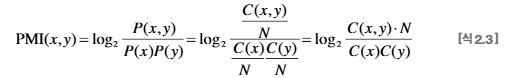   
- 식에 따라 동시발생 행렬로부터 PMI를 구할 수 있음
- 그러면 식대로 구체적인 계산을 해보면
    - 말뭉치의 단어 수(N)를 10,000이라 하고, 'the'와 'car'와 'drive'가 각 1,000번, 20번, 10번 등장했다고 하고
    - 'the'와 'car'의 동시발생 수는 10회, 'car'와 'drive'의 동시발생 수는 5회라고 가정
    - 이 조건이라면, 동시발생 횟수 관점에서는 'car'는 'drive'보다 'the'와 관련이 깊다고 나옴 
- 그렇다면 PMI 관점에서 PMI 계산 결과는 다음과 같음   
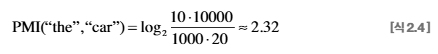   
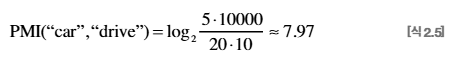   
- 이 결과에서 알 수 있듯이 PMI를 이용하면 'car'는 'the'보다 'drive'와의 관련성이 강해짐 - 우리가 원하던 결과
- 이러한 결과가 나온 이유는 단어가 단독으로 출현하는 횟수가 고려되었기 때문 
- 이 예에서는 'the'가 자주 출현했으므로 PMI 점수가 낮아진 것
- 참고로 앞의 식에서 ≈ 기호는 '거의 같음'을 뜻하는 기호   

이제 PMI라는 척도를 얻었지만 PMI에도 한 가지 문제가 있음  
바로 두 단어의 동시발생 횟수가 0이면 가 된다는 점   
이 문제를 피하기 위해 실제로 구현할 때는 **양의 상호정보량(Positive PMI)(PPMI)** 을 사용함   
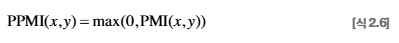   
- 이 식에 따라 PMI가 음수일 때는 0으로 취급함
- 이제 단어 사이의 관련성을 0 이상의 실수로 나타낼 수 있음   

그러면 동시발생 행렬을 PPMI 행렬로 변환하는 함수를 구현해보기   
이 함수의 이름은 ppmi(C, verbose=False, eps=1e-8)

In [32]:
def ppmi(C, verbose=False, eps = 1e-8):
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C)
    S = np.sum(C, axis=0)
    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            pmi = np.log2(C[i, j] * N / (S[j]*S[i]) + eps)
            M[i, j] = max(0, pmi)

            if verbose:
                cnt += 1
                if cnt % (total//100 + 1) == 0:
                    print('%.1f%% 완료' % (100*cnt/total))
    return M

- 여기에서 인수 C는 동시발생 행렬, verbose는 진행상황 출력 여부를 결정하는 플래그
- 큰 말뭉치를 다룰 때 verbose=True로 설정하면 중간중간 진행 상황을 알려줌
- 참고로, 이 코드는 동시발생 행렬에 대해서만 PPMI 행렬을 구할 수 있도록 하고자 단순화해 구현했음
- 구체적으로 말하면, 단어 x와 y가 동시에 발생하는 횟수를 C(x, y)라 했을 때, 가 되도록 (즉, 근삿값을 구하도록) 구현했음
- 한 가지 더, 이 코드에서는 np.log2(0)이 음의 무한대(-inf)가 되는 사태를 피하기 위해 eps라는 작은 값을 사용했음   

> '벡터 간 유사도' 절에서는 '0으로 나누기' 오류를 막기 위해 분모에 작은 값을 더했음   
> 이번에도 마찬가지로 np.log2(x) 계산을 np.log2(x + eps)로 수정하여 값이 음의 무한대로 빠지는 사태를 예방했음    

그럼 동시발생 행렬을 PPMI 행렬로 변환해보면

In [33]:
text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)
W = ppmi(C)

np.set_printoptions(precision=3)  # 유효 자릿수를 세 자리로 표시
print('동시발생 행렬')
print(C)
print('-'*50)
print('PPMI')
print(W)

동시발생 행렬
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]
--------------------------------------------------
PPMI
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]


- 이것으로 동시발생 행렬을 PPMI 행렬로 변환하는 법을 알아봤음
- 이때 PPMI 행렬의 각 원소는 0 이상의 실수
- 이제 더 좋은 척도로 이뤄진 행렬(더 좋은 단어 벡터)을 얻었음   

그러나 PPMI 행렬에도 여전히 큰 문제가 있음
말뭉치의 어휘 수가 증가함에 따라 각 단어 벡터의 차원 수도 증가한다는 문제   
- 예를 들어 말뭉치의 어휘 수가 10만 개라면 그 벡터의 차원 수도 똑같이 10만이 됨
- 10만 차원의 벡터를 다룬다는 것은 그다지 현실적이지 않음
- 또한, 이 행렬의 내용을 들여다보면 원소 대부분이 0인 것을 알 수 있음
- 벡터의 원소 대부분이 중요하지 않다는 뜻
- 다르게 표현하면 각 원소의 '중요도'가 낮다는 뜻
- 더구나 이런 벡터는 노이즈에 약하고 견고하지 못하다는 약점도 있음   

이 문제에 대처하고자 자주 수행하는 기법이 바로 벡터의 차원 감소

### 차원 감소

**차원 감소(dimensionality reduction)** 는 문자 그대로 벡터의 차원을 줄이는 방법을 말함   
그러나 단순히 줄이기만 하는 게 아니라, '중요한 정보'는 최대한 유지하면서 줄이는 게 핵심    
예시로 아래 그림처럼 데이터의 분포를 고려해 중요한 '축'을 찾는 일을 수행함   
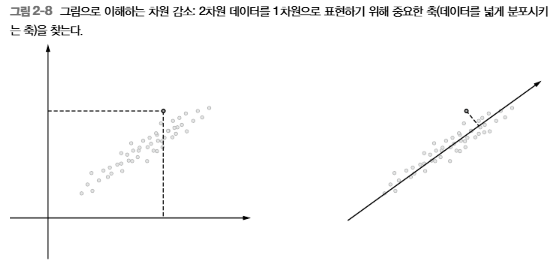   
- 그림의 왼쪽은 데이터점들을 2차원 좌표에 표시한 모습
- 그리고 오른쪽은 새로운 축을 도입하여 똑같은 데이터를 좌표축 하나만으로 표시했음(새로운 축을 찾을 때는 데이터가 넓게 분포되도록 고려해야 함)
- 이때 각 데이터점의 값은 새로운 축으로 사영된 값으로 변함
- 여기서 중요한 것은 가장 적합한 축을 찾아내는 일로, 1차원 값만으로도 데이터의 본질적인 차이를 구별할 수 있어야 함
- 이와 같은 작업은 다차원 데이터에 대해서도 수행할 수 있음   

> 원소 대부분이 0인 행렬 또는 벡터를 '희소행렬(sparse matrix)' 또는 '희소벡터(sparse vector)'라 함   
> 차원 감소의 핵심은 희소벡터에서 중요한 축을 찾아내어 더 적은 차원으로 다시 표현하는 것인데,   
> 차원 감소의 결과로 원래의 희소벡터는 원소 대부분이 0이 아닌 값으로 구성된 '밀집벡터'로 변환됨 - 이 조밀한 벡터가 여기서 원하는 단어의 분산 표현   

차원을 감소시키는 방법은 여러 가지이지만, 여기선 **특잇값분해(Singular Value Decomposition)(SVD)** 를 이용   
SVD는 임의의 행렬을 세 행렬의 곱으로 분해하며, 수식으로는 다음과 같음   
   
- 식과 같이 SVD는 임의의 행렬 X를 U, S, V라는 세 행렬의 곱으로 분해함
- U와 V는 직교행렬(orthogonal matrix)이고, 그 열벡터는 서로 직교함   
- 또한 S는 대각행렬(diagonal matrix)(대각성분 외에는 모두 0인 행렬)   
- 이 수식을 시각적으로 표현한 것이 아래 그림   
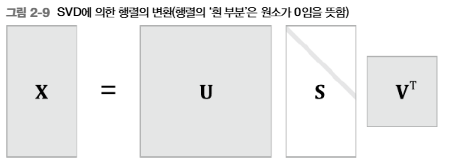   
- 식에서 U는 직교행렬 
- 그리고 이 직교행렬은 어떠한 공간의 축(기저)을 형성함
- 지금 맥락에서는 이 U 행렬을 '단어 공간'으로 취급할 수 있음
- 또한 S는 대각행렬로, 그 대각성분에는 '특잇값(singular value)'이 큰 순서로 나열되어 있음
- 특잇값이란, 쉽게 말해 '해당 축'의 중요도라고 간주할 수 있음
- 그래서 아래 그림과 같이 중요도가 낮은 원소(특잇값이 작은 원소)를 깎아내는 방법을 생각할 수 있음   
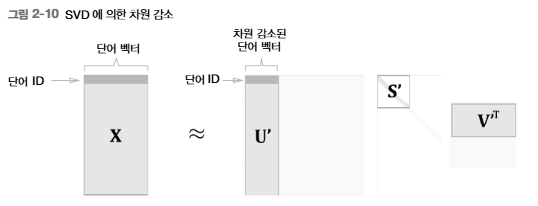   
- 행렬 S에서 특잇값이 작다면 중요도가 낮다는 뜻이므로, 행렬 U에서 여분의 열벡터를 깎아내어 원래의 행렬을 근사할 수 있음
- 이를 현재 문제로 가져와서 '단어의 PPMI 행렬'에 적용해보면
- 행렬 X의 각 행에는 해당 단어 ID의 단어 벡터가 저장되어 있으며, 그 단어 벡터가 행렬 U'라는 차원 감소된 벡터로 표현되는 것   

### SVD에 의한 차원 감소

이제 SVD를 파이썬 코드로 살펴보기   
SVD는 넘파이의 linalg 모듈이 제공하는 svd 메서드로 실행할 수 있음   
참고로, 'linalg'는 선형대수(linear algebra)의 약어   
그럼, 동시발생 행렬을 만들어 PPMI 행렬로 변환한 다음 SVD를 적용해보면

[0 1 0 0 0 0 0]
[0.    1.807 0.    0.    0.    0.    0.   ]
[ 3.409e-01 -2.220e-16 -1.193e-15  1.205e-01 -1.110e-16  9.323e-01
  4.384e-17]


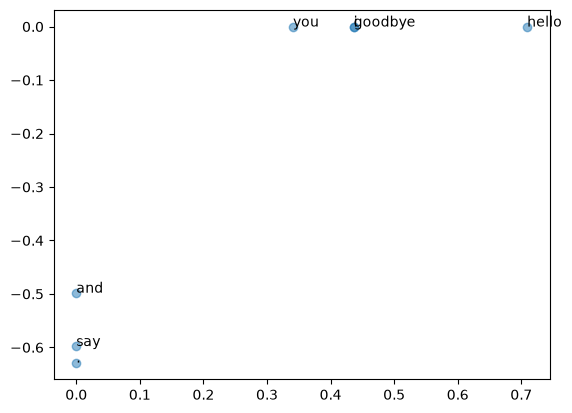

In [34]:
import matplotlib.pyplot as plt

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(id_to_word)
C = create_co_matrix(corpus, vocab_size, window_size=1)
W = ppmi(C)

# SVD
U, S, V = np.linalg.svd(W)

np.set_printoptions(precision=3)  # 유효 자릿수를 세 자리로 표시
print(C[0])
print(W[0])
print(U[0])

# 플롯
for word, word_id in word_to_id.items():
    plt.annotate(word, (U[word_id, 0], U[word_id, 1]))
plt.scatter(U[:,0], U[:,1], alpha=0.5)
plt.show()

- 이제 SVD를 수행할 수 있음   
- 이 코드에서 SVD에 의해 변환된 밀집벡터 표현은 변수 U에 저장됨   

제 내용을 살표보기   
단어 ID가 0인 단어 벡터를 봄

In [36]:
print(C[0])  # 동시발생 행렬
print(W[0])  # PPMI 행렬
print(U[0])  # SVD

[0 1 0 0 0 0 0]
[0.    1.807 0.    0.    0.    0.    0.   ]
[ 3.409e-01 -2.220e-16 -1.193e-15  1.205e-01 -1.110e-16  9.323e-01
  4.384e-17]


- 이 결과에서 보듯 원래는 희소벡터인 W[0]가 SVD에 의해서 밀집벡터 U[0]로 변했음
- 그리고 이 밀집벡터의 차원을 감소시키려면, 
- 예컨대 2차원 벡터로 줄이려면 단순히 처음의 두 원소를 꺼내면 됨

In [37]:
print(U[0, :2])

[ 3.409e-01 -2.220e-16]


- 이것으로 차원 감소도 다 알아봤음   

그러면 각 단어를 2차원 벡터로 표현한 후 그래프로 그려보면

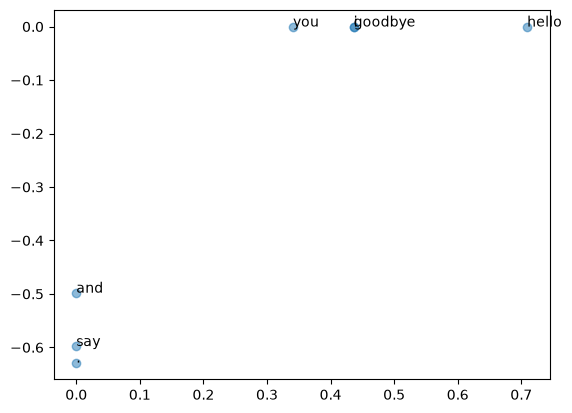

In [39]:
for word, word_id in word_to_id.items():
    plt.annotate(word, (U[word_id, 0], U[word_id, 1]))

plt.scatter(U[:,0], U[:,1], alpha=0.5)
plt.show()

- plt.annotate(word, x, y) 메서드는 2차원 그래프상에서 좌표 (x, y) 지점에 word에 담긴 텍스트를 그림   

이 코드를 실행하면 화면에 아래 그림이 나타남   
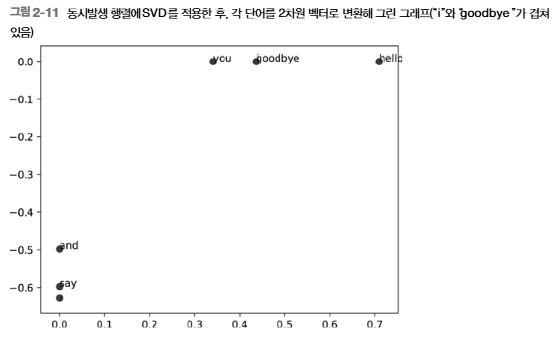   
- 그림을 보면 'goodbye'와 'hello', 'you'와 'i'가 제법 가까이 있음을 알 수 있음 - 우리의 직관과 비교적 비슷함
- 하지만 지금 사용한 말뭉치가 아주 작아서 이 결과를 그대로 받아들이기에는 석연치 않음
- 그러면 계속해서 PTB 데이터셋이라는 더 큰 말뭉치를 사용하여 똑같은 실험을 수행해봄   

우선은 PTB 데이터셋이 무엇인지부터 간단히 설명함   

> 행렬의 크기가 N이면 SVD 계산은 O(N3)이 걸림 - 계산량이 N의 3 제곱에 비례해 늘어난다는 뜻   
> 이는 현실적으로 감당하기 어려운 수준이므로 Truncated SVD 같은 더 빠른 기법을 이용함   
> Truncated SVD는 특잇값이 작은 것은 버리는(truncated) 방식으로 성능 향상을 꾀함   
> 다음 절에서도 옵션으로 사이킷런(scikit-learn) 라이브러리의 Truncated SVD를 이용함

### PTB 데이터셋

지금까지는 아주 작은 텍스트 데이터를 말뭉치로 사용했음   
그래서 이번 절에서는 '본격적인' 말뭉치(그렇다고 너무 크지는 않고 적당한 말뭉치)를 이용해봄   
그 주인공은 바로 **펜 트리뱅크(Penn Treebank)(PTB)**   

> PTB 말뭉치는 주어진 기법의 품질을 측정하는 벤치마크로 자주 이용됨   
> 이 책에서도 PTB 말뭉치를 이용하여 다양한 실험을 수행함   

여기서 이용할 PTB 말뭉치는 word2vec의 발명자인 토마스 미콜로프(Tomas Mikolov)의 웹 페이지에서 받을 수 있음   
이 PTB 말뭉치는 텍스트 파일로 제공되며, 원래의 PTB 문장에 몇 가지 전처리를 해두었음   
예컨대 희소한 단어를 \<unk>라는 특수 문자로 치환한다거나('unk'는 'unknown'의 약어), 구체적인 숫자를 'N'으로 대체하는 등의 작업이 적용되었음   
참고로 아래 그림은 이 PTB 말뭉치의 내용을 보여줌   
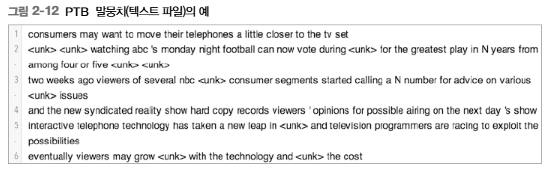   
- 그림에서 보듯 PTB 말뭉치에서는 한 문장이 하나의 줄로 저장되어 있음
- 이 책에서는 각 문장을 연결한 '하나의 큰 시계열 데이터'로 취급함
- 이때 각 문장 끝에 \<eos>라는 특수 문자를 삽입함('eos'는 'end of sentence'의 약어)   

> 이 책에서는 문장의 구분을 고려하지 않고, 여러 문장을 연결한 '하나의 큰 시계열 데이터'로 간주함   
> 물론 문장 단위로 처리할 수도 있지만(예컨대 단어의 빈도를 문장 단위로 계산), 이 책에서는 원리를 간단히 보여주고자 문장 단위 처리는 수행하지 않음   

이 책에서는 PTB 데이터셋을 쉽게 이용할 수 있도록 전용 파이썬 코드를 준비했음   
이 코드는 dataset/ptb.py 파일에 담겨 있음

In [40]:
import sys
sys.path.append('..')
from dataset import ptb


corpus, word_to_id, id_to_word = ptb.load_data('train')

print('말뭉치 크기:', len(corpus))
print('corpus[:30]:', corpus[:30])
print()
print('id_to_word[0]:', id_to_word[0])
print('id_to_word[1]:', id_to_word[1])
print('id_to_word[2]:', id_to_word[2])
print()
print("word_to_id['car']:", word_to_id['car'])
print("word_to_id['happy']:", word_to_id['happy'])
print("word_to_id['lexus']:", word_to_id['lexus'])

Done
말뭉치 크기: 929589
corpus[:30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

id_to_word[0]: aer
id_to_word[1]: banknote
id_to_word[2]: berlitz

word_to_id['car']: 3856
word_to_id['happy']: 4428
word_to_id['lexus']: 7426


- 말뭉치를 다루는 방법은 지금까지와 같음
- corpus에는 단어 ID 목록이 저장됨
- id_to_word는 단어 ID에서 단어로 변환하는 딕셔너리이고, word_to_id는 단어에서 단어 ID로 변환하는 딕셔너리   
- ptb.load_data()는 데이터를 읽어 들임
- 이때 인수로는 'train', 'test', 'valid' 중 하나를 지정할 수 있는데, 차례대로 '훈련용', '테스트용', '검증용' 데이터를 가리킴   

이상으로 ptb 사용법에 관한 설명을 마침

### PTB 데이터셋 평가

PTB 데이터셋에 통계 기반 기법을 적용해보기   
이번에는 큰 행렬에 SVD를 적용해야 하므로 고속 SVD를 이용할 것을 추천   
고속 SVD를 이용하려면 sklearn 모듈을 설치해야 함   
물론 간단한 SVD(np.linalg.svd())도 사용할 수 있지만, 시간이 오래 걸리며 메모리도 훨씬 많이 사용함

In [42]:
import sys
sys.path.append('..')
import numpy as np
from dataset import ptb


window_size = 2
wordvec_size = 100

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
print('동시발생 수 계산 ...')
C = create_co_matrix(corpus, vocab_size, window_size)
print('PPMI 계산 ...')
W = ppmi(C, verbose=True)

print('calculating SVD ...')
try:
    # truncated SVD (빠름)
    from sklearn.utils.extmath import randomized_svd
    U, S, V = randomized_svd(W, n_components=wordvec_size, n_iter=5,
                             random_state=None)
except ImportError:
    # SVD (느림)
    U, S, V = np.linalg.svd(W)

word_vecs = U[:, :wordvec_size]

querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)

동시발생 수 계산 ...
PPMI 계산 ...
1.0% 완료
2.0% 완료
3.0% 완료
4.0% 완료
5.0% 완료
6.0% 완료
7.0% 완료
8.0% 완료
9.0% 완료
10.0% 완료
11.0% 완료
12.0% 완료
13.0% 완료
14.0% 완료
15.0% 완료
16.0% 완료
17.0% 완료
18.0% 완료
19.0% 완료
20.0% 완료
21.0% 완료
22.0% 완료
23.0% 완료
24.0% 완료
25.0% 완료
26.0% 완료
27.0% 완료
28.0% 완료
29.0% 완료
30.0% 완료
31.0% 완료
32.0% 완료
33.0% 완료
34.0% 완료
35.0% 완료
36.0% 완료
37.0% 완료
38.0% 완료
39.0% 완료
40.0% 완료
41.0% 완료
42.0% 완료
43.0% 완료
44.0% 완료
45.0% 완료
46.0% 완료
47.0% 완료
48.0% 완료
49.0% 완료
50.0% 완료
51.0% 완료
52.0% 완료
53.0% 완료
54.0% 완료
55.0% 완료
56.0% 완료
57.0% 완료
58.0% 완료
59.0% 완료
60.0% 완료
61.0% 완료
62.0% 완료
63.0% 완료
64.0% 완료
65.0% 완료
66.0% 완료
67.0% 완료
68.0% 완료
69.0% 완료
70.0% 완료
71.0% 완료
72.0% 완료
73.0% 완료
74.0% 완료
75.0% 완료
76.0% 완료
77.0% 완료
78.0% 완료
79.0% 완료
80.0% 완료
81.0% 완료
82.0% 완료
83.0% 완료
84.0% 완료
85.0% 완료
86.0% 완료
87.0% 완료
88.0% 완료
89.0% 완료
90.0% 완료
91.0% 완료
92.0% 완료
93.0% 완료
94.0% 완료
95.0% 완료
96.0% 완료
97.0% 완료
98.0% 완료
99.0% 완료
calculating SVD ...

[query] you
 i: 0.8559516072273254
 we: 0.8327416181564331
 they: 0.717

- 이 코드는 SVD를 수행하는 데 sklearn의 randomized_svd() 메서드를 이용했음
- 이 메서드는 무작위 수를 사용한 Truncated SVD로, 특잇값이 큰 것들만 계산하여 기본적인 SVD보다 훨씬 빠름
- 나머지 부분은 앞서 작은 말뭉치를 사용한 코드와 거의 같음   
- 결과를 보면, 우선 'you'라는 검색어에서는 인칭대명사인 'i'와 'we'가 상위를 차지했음을 알 수 있음
- 영어 문장에서 관용적으로 자주 같이 나오는 단어들이기 때문 
    - 또, 'year'의 연관어로는 'month'와 'quarter'가, 'car'의 연관어로는 'auto'와 'vehicle' 등이 뽑힘
    - 그리고 'toyota'와 관련된 단어로는 'nissan', 'honda', 'lexus' 등 자동차 제조업체나 브랜드가 뽑힌 것도 확인할 수 있음
- 이처럼 단어의 의미 혹은 문법적인 관점에서 비슷한 단어들이 가까운 벡터로 나타났음 - 우리의 직관과 비슷한 결과   

마침내 '단어의 의미'를 벡터로 잘 인코딩하는 데 성공   
말뭉치를 사용해 맥락에 속한 단어의 등장 횟수를 센 후 PPMI 행렬로 변환하고, 다시 SVD를 이용해 차원을 감소시킴으로써 더 좋은 단어 벡터를 얻어냈음   
이것이 단어의 분산 표현이고, 각 단어는 고정 길이의 밀집벡터로 표현되었음   

이번 장에서는 단어 몇 가지만 선택하여 유사 단어를 살펴봤음   
하지만 다른 수많은 단어에서도 같은 성질을 확인할 수 있을 것   
또한 대규모 말뭉치를 사용하면 단어의 분산 표현의 품질도 더 좋아질 것

## 정리

이번 장에서는 자연어를 대상으로, 특히 컴퓨터에게 '단어의 의미' 이해시키기를 주제로 이야기를 진행했음   
이 목적을 달성하기 위한 여정으로, 먼저 시소러스를 이용한 기법을 설명하고, 이어서 통계 기반 기법을 살펴봤음   

시소러스 기반 기법에서는 단어들의 관련성을 사람이 수작업으로 하나씩 정의   
이 작업은 매우 힘들고 (느낌의 미세한 차이를 나타낼 수 없는 등) 표현력에도 한계가 있음   

한편, 통계 기반 기법은 말뭉치로부터 단어의 의미를 자동으로 추출하고, 그 의미를 벡터로 표현함 구체적으로는 단어의 동시발생 행렬을 만들고,   
PPMI 행렬로 변환한 다음, 안전성을 높이기 위해 SVD를 이용해 차원을 감소시켜 각 단어의 분산 표현을 만들어냄   
그리고 그 분산 표현에 따르면 의미가 (그리고 문법적인 용법면에서) 비슷한 단어들이 벡터 공간에서도 서로 가까이 모여 있음을 확인했음   

또한 이번 장에서는 말뭉치의 텍스트 데이터를 다루기 쉽게 해주는 전처리 함수를 몇 개 구현했음   
벡터 간 유사도를 측정하는 cos_similarity() 함수, 유사 단어의 랭킹을 표시하는 most_similar() 함수 - 이 함수들은 다음 장 이후에도 사용함

### 이번 장에서 배운 내용

- WordNet 등의 시소러스를 이용하면 유의어를 얻거나 단어 사이의 유사도를 측정하는 등 유용한 작업을 할 수 있음
- 시소러스 기반 기법은 시소러스를 작성하는 데 엄청난 인적 자원이 든다거나 새로운 단어에 대응하기 어렵다는 문제가 있음
- 현재는 말뭉치를 이용해 단어를 벡터화하는 방식이 주로 쓰임
- 최근의 단어 벡터화 기법들은 대부분 '단어의 의미는 주변 단어에 의해 형성된다'는 분포 가설에 기초함
- 통계 기반 기법은 말뭉치 안의 각 단어에 대해서 그 단어의 주변 단어의 빈도를 집계함(동시발생 행렬)
- 동시발생 행렬을 PPMI 행렬로 변환하고 다시 차원을 감소시킴으로써, 거대한 '희소벡터'를 작은 '밀집벡터'로 변환할 수 있음
- 단어의 벡터 공간에서는 의미가 가까운 단어는 그 거리도 가까울 것으로 기대됨